# <span style="color:#0f766e; font-weight:700;">Analiza Danych (Python) — Lekcja 7: Rozkłady, symulacje i CTG</span>

1. [Rozkłady stosowane w statystyce](#1.-Rozkłady-stosowane-w-statystyce)
2. [Rozkład t-Studenta](#2.-Rozkład-t-Studenta)
3. [Rozkład chi-kwadrat](#3.-Rozkład-chi-kwadrat)
4. [Symulacje Monte Carlo](#4.-Symulacje-Monte-Carlo)
5. [Centralne Twierdzenie Graniczne](#5.-Centralne-Twierdzenie-Graniczne)
6. [Błąd standardowy](#6.-Błąd-standardowy)
7. [Importy i środowisko](#7.-Importy-i-środowisko)
8. [Przykłady](#8.-Przykłady)
9. [Zadania obowiązkowe](#9.-Zadania-obowiązkowe)
10. [Zadania dodatkowe](#10.-Zadania-dodatkowe)
11. [Najczęstsze błędy](#11.-Najczęstsze-błędy)

# <span style="color:#0f766e; font-weight:700;">1. Rozkłady stosowane w statystyce</span>

W statystyce klasycznej kilka rozkładów pojawia się wyjątkowo często — nie dlatego że są matematycznie wygodne, lecz dlatego że wynikają bezpośrednio z danych i procedur wnioskowania.

## <span style="color:#0f766e; font-weight:700;">Przegląd</span>

| Rozkład | Symbol | Zastosowanie |
|---|---|---|
| Normalny | N(μ, σ) | rozkład danych ciągłych, aproksymacja, CTG |
| t-Studenta | t(df) | wnioskowanie o μ przy nieznanym σ, małe próby |
| chi-kwadrat | χ²(df) | testy zgodności, wnioskowanie o wariancji |
| F | F(df₁, df₂) | porównanie wariancji, ANOVA |
| Dwumianowy | Bin(n,p) | dane dychotomiczne, testy proporcji |
| Poissona | Poi(λ) | dane zliczeniowe, rzadkie zdarzenia |

## <span style="color:#0f766e; font-weight:700;">Skąd biorą się t, χ², F?</span>

Wszystkie trzy wywodzą się z rozkładu normalnego:
- **χ²(k)** = suma kwadratów k niezależnych zmiennych N(0,1),
- **t(k)** = N(0,1) / √(χ²(k)/k) — iloraz normalnej i pierwiastka ze znormalizowanej chi-kwadrat,
- **F(k₁,k₂)** = (χ²(k₁)/k₁) / (χ²(k₂)/k₂) — iloraz dwóch znormalizowanych chi-kwadrat.

# <span style="color:#0f766e; font-weight:700;">2. Rozkład t-Studenta</span>

## <span style="color:#0f766e; font-weight:700;">Definicja i parametry</span>

**t(df)** — rozkład t-Studenta z `df` stopniami swobody.
- `stats.t(df=k)`
- E[X] = 0 (dla df > 1), Var[X] = df/(df−2) (dla df > 2)

## <span style="color:#0f766e; font-weight:700;">Kluczowa właściwość: ciężkie ogony</span>

Dla małego df rozkład t ma grubsze ogony niż N(0,1) — zdarzenia ekstremalne są bardziej prawdopodobne.
Wraz ze wzrostem df rozkład t zbiega do N(0,1). Dla df ≥ 30 różnica jest praktycznie pomijalna.

## <span style="color:#0f766e; font-weight:700;">Kiedy używamy?</span>

Gdy szacujemy lub testujemy średnią μ populacji, ale **nie znamy σ** i szacujemy ją z próby:
- statystyka testowa t = (x̄ − μ₀) / (s / √n) ma rozkład t(n−1),
- gdzie s to odchylenie standardowe z próby.

## <span style="color:#0f766e; font-weight:700;">Porównanie ogonów</span>

| df | P(\|t\| > 2) | P(\|t\| > 3) |
|---|---|---|
| 1 | 0.295 | 0.205 |
| 5 | 0.102 | 0.030 |
| 10 | 0.074 | 0.015 |
| 30 | 0.055 | 0.006 |
| ∞ (N(0,1)) | 0.046 | 0.003 |

# <span style="color:#0f766e; font-weight:700;">3. Rozkład chi-kwadrat</span>

## <span style="color:#0f766e; font-weight:700;">Definicja i parametry</span>

**χ²(df)** — suma kwadratów `df` niezależnych zmiennych N(0,1).
- `stats.chi2(df=k)`
- E[X] = df, Var[X] = 2·df
- Rozkład jest **silnie prawostronnie skośny** dla małych df; symetryzuje się przy dużych df.

## <span style="color:#0f766e; font-weight:700;">Kiedy używamy?</span>

- **Test zgodności χ²**: czy dane empiryczne pasują do oczekiwanego rozkładu?
- **Test niezależności**: czy dwie zmienne kategoryczne są niezależne?
- **Wnioskowanie o wariancji**: przedział ufności dla σ².

## <span style="color:#0f766e; font-weight:700;">Kluczowe kwantyle</span>

Dla df=10:
- χ²(0.025) ≈ 3.25 (dolny kraniec przedziału 95%)
- χ²(0.975) ≈ 20.48 (górny kraniec przedziału 95%)

W scipy: `stats.chi2(df=10).ppf(0.025)` i `stats.chi2(df=10).ppf(0.975)`.

# <span style="color:#0f766e; font-weight:700;">4. Symulacje Monte Carlo</span>

## <span style="color:#0f766e; font-weight:700;">Idea</span>

**Metoda Monte Carlo** polega na wielokrotnym losowaniu i zliczaniu zdarzeń, żeby oszacować prawdopodobieństwa lub wartości, których nie potrafimy (lub nie chcemy) obliczyć analitycznie.

Schemat:
1. Zdefiniuj eksperyment losowy.
2. Powtórz go N razy (N = 10 000–1 000 000).
3. Policz, jak często zaszło interesujące zdarzenie.
4. Oszacowanie: P(zdarzenie) ≈ liczba_sukcesów / N.

## <span style="color:#0f766e; font-weight:700;">Zastosowania</span>

- Szacowanie prawdopodobieństwa złożonych zdarzeń,
- Numeryczne całkowanie (gdy całka analityczna jest trudna),
- Symulacja procesów finansowych, fizycznych, biologicznych,
- Weryfikacja wzorów i twierdzeń probabilistycznych.

## <span style="color:#0f766e; font-weight:700;">Dokładność</span>

Błąd standardowy oszacowania MC: SE ≈ √(p(1−p)/N).
Dla N=10 000 i p≈0.5: SE ≈ 0.005 — dokładność do 2 miejsc po przecinku.

# <span style="color:#0f766e; font-weight:700;">5. Centralne Twierdzenie Graniczne</span>

## <span style="color:#0f766e; font-weight:700;">Twierdzenie (wersja intuicyjna)</span>

Jeśli losujemy **niezależne próby** rozmiaru n z **dowolnego** rozkładu o skończonej wariancji, to rozkład **średniej próbkowej** x̄ zbiega do rozkładu normalnego gdy n → ∞:

$$\bar{X} \sim N\!\left(\mu,\, \frac{\sigma}{\sqrt{n}}\right)$$

gdzie μ i σ to parametry rozkładu populacji.

## <span style="color:#0f766e; font-weight:700;">Co to oznacza w praktyce?</span>

- **Nie musimy znać rozkładu populacji** — jeśli n jest wystarczająco duże, średnia i tak ma rozkład normalny.
- Reguła praktyczna: n ≥ 30 zwykle wystarcza (wyjątek: bardzo skośne rozkłady).
- Im bardziej symetryczny rozkład populacji, tym szybsza zbieżność.

## <span style="color:#0f766e; font-weight:700;">Warunki CTG</span>

1. Próby są **niezależne**.
2. Rozkład populacji ma **skończoną wariancję**.
3. n jest **wystarczająco duże** (zależy od skośności rozkładu).

# <span style="color:#0f766e; font-weight:700;">6. Błąd standardowy</span>

## <span style="color:#0f766e; font-weight:700;">Definicja</span>

**Błąd standardowy** (SE, *Standard Error*) to odchylenie standardowe rozkładu próbkowania statystyki.

Dla średniej:

$$SE(\bar{X}) = \frac{\sigma}{\sqrt{n}}$$

Jeśli σ jest nieznane, szacujemy je przez s (odchylenie z próby):

$$\widehat{SE} = \frac{s}{\sqrt{n}}$$

## <span style="color:#0f766e; font-weight:700;">Interpretacja</span>

- SE mierzy, jak bardzo średnia z próby **różni się od próby do próby**.
- Im większa próba, tym mniejszy SE — wyniki są bardziej powtarzalne.
- SE **≠** odchylenie standardowe danych (s mierzy rozproszenie obserwacji, SE mierzy precyzję oszacowania).

## <span style="color:#0f766e; font-weight:700;">Konsekwencje</span>

| Wzrost n (4×) | Efekt na SE |
|---|---|
| n → 4n | SE → SE/2 (dwukrotna poprawa) |
| n → 9n | SE → SE/3 |
| n → 100n | SE → SE/10 |

Poprawienie precyzji 10-krotnie wymaga 100-krotnie większej próby — **prawo malejących zwrotów**.

# <span style="color:#0f766e; font-weight:700;">7. Importy i środowisko</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Ustawienia globalne wykresów
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Biblioteki wczytane pomyślnie.")

Biblioteki wczytane pomyślnie.


# <span style="color:#0f766e; font-weight:700;">8. Przykłady</span>

## <span style="color:#0f766e; font-weight:700;">Przykład 1: Rozkład t-Studenta — porównanie z rozkładem normalnym</span>

Cięższe ogony rozkładu t oznaczają, że ekstremalne wartości są bardziej prawdopodobne niż w N(0,1). Efekt jest wyraźny dla małego df i zanika przy df ≥ 30.

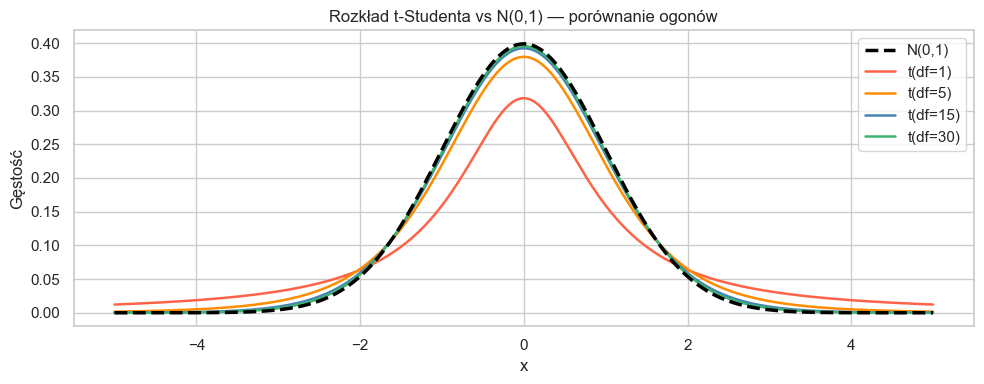

P(|X| > 2):
  N(0,1)  : 0.0455
  t(df= 1): 0.2952
  t(df= 5): 0.1019
  t(df=15): 0.0639
  t(df=30): 0.0546


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(-5, 5, 400)
dist_norm = stats.norm(0, 1)

# Wykres porównawczy pdf
plt.figure(figsize=(10, 4))
plt.plot(x, dist_norm.pdf(x), color='black', lw=2.5, linestyle='--', label='N(0,1)', zorder=5)
kolory = ['tomato', 'darkorange', 'steelblue', 'mediumseagreen']
for df, kolor in zip([1, 5, 15, 30], kolory):
    plt.plot(x, stats.t(df=df).pdf(x), color=kolor, lw=1.8, label=f't(df={df})')

plt.xlabel('x')
plt.ylabel('Gęstość')
plt.title('Rozkład t-Studenta vs N(0,1) — porównanie ogonów')
plt.legend()
plt.tight_layout()
plt.show()

# Prawdopodobieństwo ogonów: P(|t| > 2)
print("P(|X| > 2):")
print(f"  N(0,1)  : {2*(1 - dist_norm.cdf(2)):.4f}")
for df in [1, 5, 15, 30]:
    p = 2 * (1 - stats.t(df=df).cdf(2))
    print(f"  t(df={df:2d}): {p:.4f}")

## <span style="color:#0f766e; font-weight:700;">Przykład 2: Rozkład chi-kwadrat — pdf i kluczowe kwantyle</span>

Chi-kwadrat jest prawostronnie skośny dla małych df. Kwantyle χ² są używane w przedziałach ufności dla wariancji i testach zgodności.

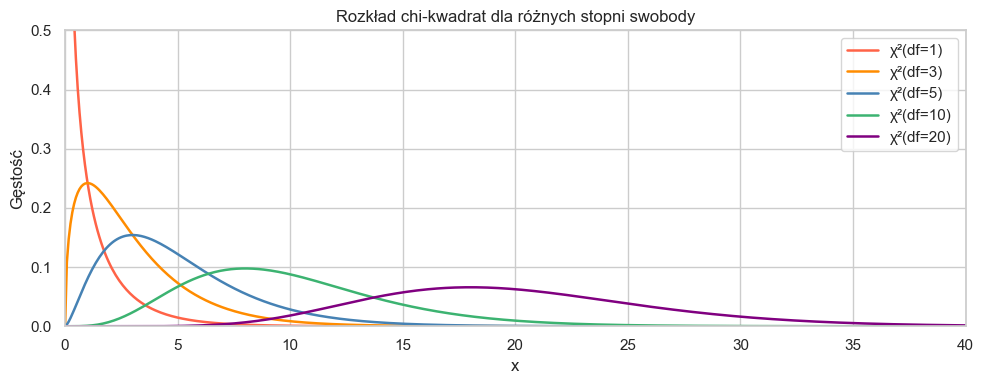


Kwantyle χ²(df=10):
  ppf(0.025) = 3.2470
  ppf(0.050) = 3.9403
  ppf(0.500) = 9.3418
  ppf(0.950) = 18.3070
  ppf(0.975) = 20.4832

E[X]   = 10.00  (= df = 10)
Var[X] = 20.00  (= 2·df = 20)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

x = np.linspace(0, 40, 500)

# Wykres pdf dla różnych df
plt.figure(figsize=(10, 4))
kolory = ['tomato', 'darkorange', 'steelblue', 'mediumseagreen', 'purple']
for df, kolor in zip([1, 3, 5, 10, 20], kolory):
    dist = stats.chi2(df=df)
    y = dist.pdf(x)
    plt.plot(x, y, color=kolor, lw=1.8, label=f'χ²(df={df})')

plt.xlabel('x')
plt.ylabel('Gęstość')
plt.title('Rozkład chi-kwadrat dla różnych stopni swobody')
plt.legend()
plt.xlim(0, 40)
plt.ylim(0, 0.5)
plt.tight_layout()
plt.show()

# Kluczowe kwantyle dla df=10
df = 10
dist = stats.chi2(df=df)
print(f"\nKwantyle χ²(df={df}):")
for q in [0.025, 0.05, 0.50, 0.95, 0.975]:
    print(f"  ppf({q:.3f}) = {dist.ppf(q):.4f}")

print(f"\nE[X]   = {dist.mean():.2f}  (= df = {df})")
print(f"Var[X] = {dist.var():.2f}  (= 2·df = {2*df})")

## <span style="color:#0f766e; font-weight:700;">Przykład 3: Monte Carlo — estymacja liczby π</span>

Rzucamy punkty losowo w kwadrat [−1,1]². Punkt trafia w koło jeśli x²+y²≤1. Stosunek pól daje π/4.

N = 50,000
Szacowane π = 3.14632
Prawdziwe  π = 3.14159
Błąd absolutny = 0.00473


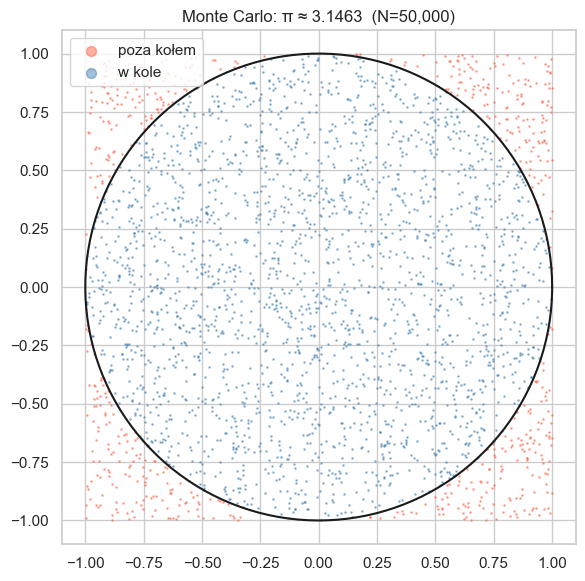

In [4]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N = 50_000

# Losowanie punktów w kwadracie [-1, 1]²
x = rng.uniform(-1, 1, size=N)
y = rng.uniform(-1, 1, size=N)

# Punkt jest w kole, jeśli x² + y² ≤ 1
w_kole = (x**2 + y**2) <= 1.0

# Estymacja: π ≈ 4 * (liczba punktów w kole) / N
pi_est = 4 * w_kole.mean()
print(f"N = {N:,}")
print(f"Szacowane π = {pi_est:.5f}")
print(f"Prawdziwe  π = {np.pi:.5f}")
print(f"Błąd absolutny = {abs(pi_est - np.pi):.5f}")

# Wizualizacja (tylko 3000 punktów dla czytelności)
n_vis = 3000
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x[:n_vis][~w_kole[:n_vis]], y[:n_vis][~w_kole[:n_vis]],
           s=0.8, color='tomato', alpha=0.5, label='poza kołem')
ax.scatter(x[:n_vis][w_kole[:n_vis]],  y[:n_vis][w_kole[:n_vis]],
           s=0.8, color='steelblue', alpha=0.5, label='w kole')
theta = np.linspace(0, 2*np.pi, 300)
ax.plot(np.cos(theta), np.sin(theta), 'k-', lw=1.5)
ax.set_aspect('equal')
ax.set_title(f'Monte Carlo: π ≈ {pi_est:.4f}  (N={N:,})')
ax.legend(markerscale=8)
plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Przykład 4: CTG — demonstracja dla rozkładu jednostajnego</span>

Rozkład jednostajny jest płaski i bardzo odległy od normalnego. Pokażemy, że rozkład średnich próbkowych szybko zbiega do normalnego.

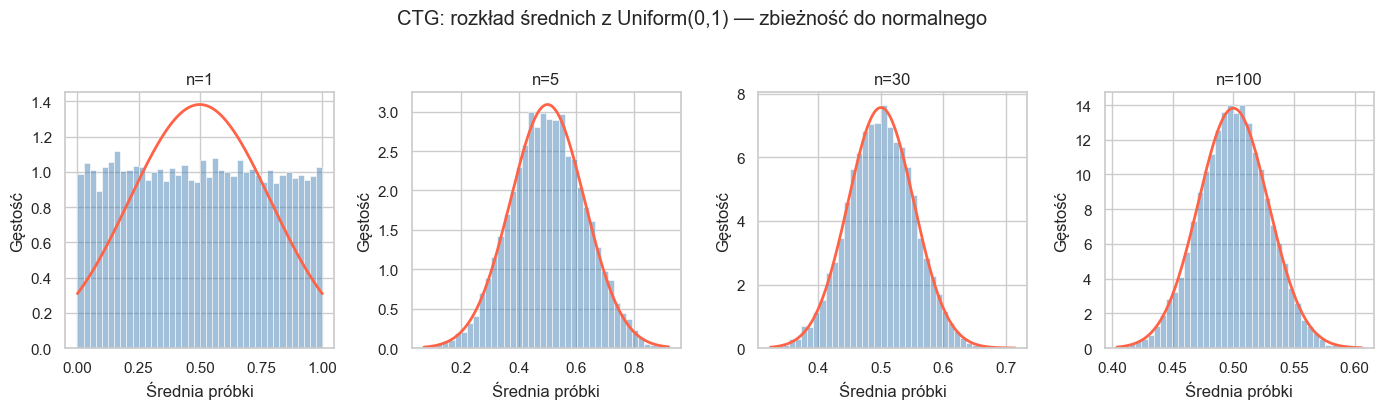

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(42)
n_symulacji = 10_000

# Parametry rozkładu jednostajnego Uniform(0, 1)
mu_pop = 0.5        # E[X] = (a+b)/2
sigma_pop = 1/np.sqrt(12)  # SD = (b-a)/sqrt(12)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
n_values = [1, 5, 30, 100]

for ax, n in zip(axes, n_values):
    # Losujemy n_symulacji próbek rozmiaru n, obliczamy średnią każdej
    probki = rng.uniform(0, 1, size=(n_symulacji, n))
    srednie = probki.mean(axis=1)

    # Histogram rozkładu średnich
    sns.histplot(srednie, stat='density', bins=40, ax=ax, color='steelblue', alpha=0.5)

    # Nakładamy teoretyczną aproksymację normalną (CTG)
    se = sigma_pop / np.sqrt(n)
    x_plot = np.linspace(srednie.min(), srednie.max(), 200)
    ax.plot(x_plot, stats.norm(mu_pop, se).pdf(x_plot), color='tomato', lw=2)
    ax.set_title(f'n={n}')
    ax.set_xlabel('Średnia próbki')
    ax.set_ylabel('Gęstość')

fig.suptitle('CTG: rozkład średnich z Uniform(0,1) — zbieżność do normalnego', y=1.02)
plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Przykład 5: CTG — demonstracja dla rozkładu Poissona (skośnego)</span>

Rozkład Poissona jest prawostronnie skośny. CTG działa wolniej niż dla rozkładu jednostajnego.

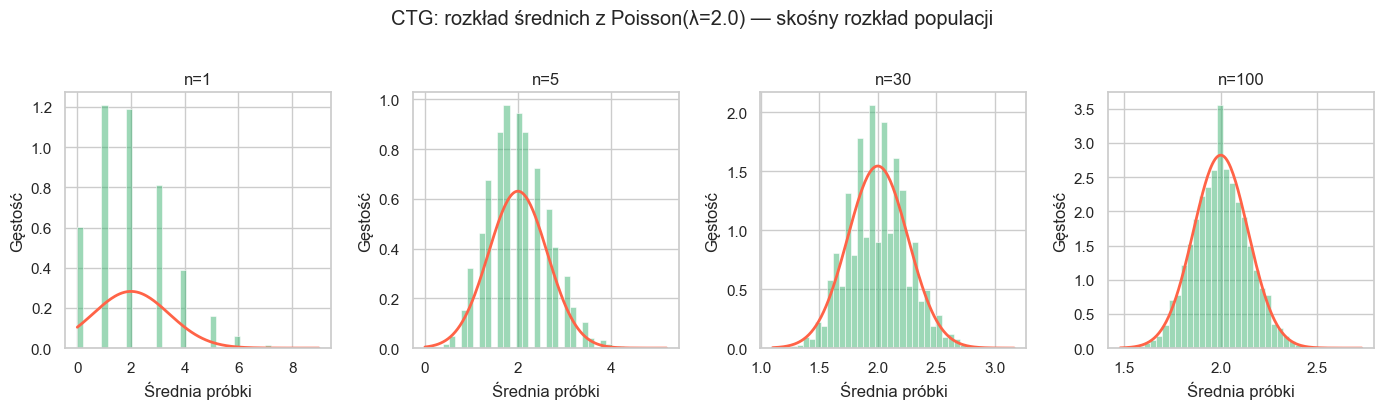

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

rng = np.random.default_rng(42)
n_symulacji = 10_000
lam = 2.0  # parametr Poissona — skośny rozkład

mu_pop = lam
sigma_pop = np.sqrt(lam)

fig, axes = plt.subplots(1, 4, figsize=(14, 4))

for ax, n in zip(axes, [1, 5, 30, 100]):
    # Losowanie próbek rozmiaru n z Poissona
    probki = rng.poisson(lam, size=(n_symulacji, n))
    srednie = probki.mean(axis=1)

    sns.histplot(srednie, stat='density', bins=40, ax=ax, color='mediumseagreen', alpha=0.5)
    se = sigma_pop / np.sqrt(n)
    x_plot = np.linspace(max(0, srednie.min()), srednie.max(), 200)
    ax.plot(x_plot, stats.norm(mu_pop, se).pdf(x_plot), color='tomato', lw=2)
    ax.set_title(f'n={n}')
    ax.set_xlabel('Średnia próbki')
    ax.set_ylabel('Gęstość')

fig.suptitle(f'CTG: rozkład średnich z Poisson(λ={lam}) — skośny rozkład populacji', y=1.02)
plt.tight_layout()
plt.show()

## <span style="color:#0f766e; font-weight:700;">Przykład 6: Błąd standardowy — jak maleje z n</span>

SE = σ/√n. Pokażemy, że SE maleje proporcjonalnie do 1/√n — poprawienie precyzji wymaga coraz większych nakładów.

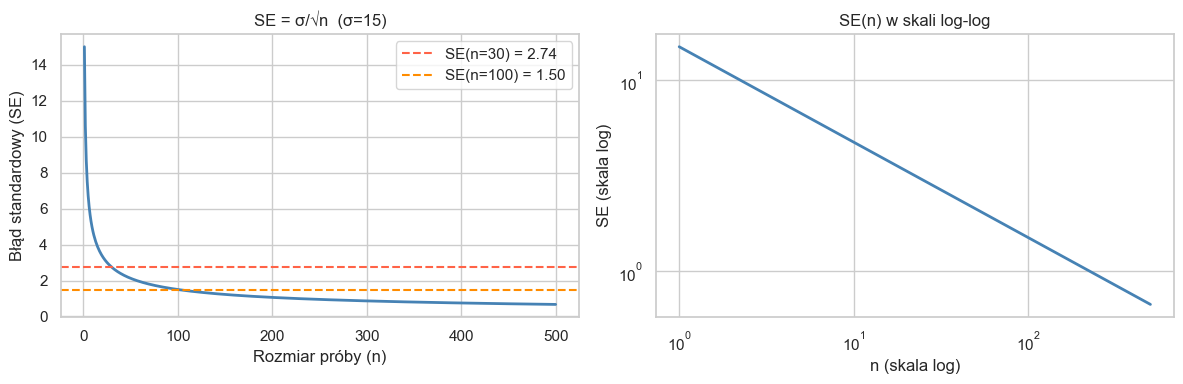

SE przy n=25:  3.000
SE przy n=100: 1.500  (4× więcej danych → 2× mniejszy SE)
SE przy n=400: 0.750  (16× więcej danych → 4× mniejszy SE)


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

sigma = 15.0  # odchylenie standardowe populacji (np. wyniki IQ)
n_values = np.arange(1, 501)

# SE = sigma / sqrt(n)
se_values = sigma / np.sqrt(n_values)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Wykres SE(n) — skala liniowa
axes[0].plot(n_values, se_values, color='steelblue', lw=2)
axes[0].axhline(sigma/np.sqrt(30), color='tomato', linestyle='--', lw=1.5, label=f'SE(n=30) = {sigma/np.sqrt(30):.2f}')
axes[0].axhline(sigma/np.sqrt(100), color='darkorange', linestyle='--', lw=1.5, label=f'SE(n=100) = {sigma/np.sqrt(100):.2f}')
axes[0].set_xlabel('Rozmiar próby (n)')
axes[0].set_ylabel('Błąd standardowy (SE)')
axes[0].set_title('SE = σ/√n  (σ=15)')
axes[0].legend()

# Wykres SE(n) — skala log-log (powinna być linią prostą)
axes[1].loglog(n_values, se_values, color='steelblue', lw=2)
axes[1].set_xlabel('n (skala log)')
axes[1].set_ylabel('SE (skala log)')
axes[1].set_title('SE(n) w skali log-log')

plt.tight_layout()
plt.show()

# Tabela: ile razy musisz zwiększyć n, żeby zmniejszyć SE 2x
print(f"SE przy n=25:  {sigma/np.sqrt(25):.3f}")
print(f"SE przy n=100: {sigma/np.sqrt(100):.3f}  (4× więcej danych → 2× mniejszy SE)")
print(f"SE przy n=400: {sigma/np.sqrt(400):.3f}  (16× więcej danych → 4× mniejszy SE)")

## <span style="color:#0f766e; font-weight:700;">Przykład 7: Monte Carlo — rozkład sumy trzech kostek</span>

Analityczne obliczenie rozkładu sumy 3 kostek jest żmudne. Monte Carlo daje wynik w kilku linijkach.

P(suma >= 15) = 0.0923
P(suma == 3)  = 0.00464  (tylko 1,1,1)
E[suma]       = 10.498  (teoretycznie: 3 * 3.5 = 10.5)


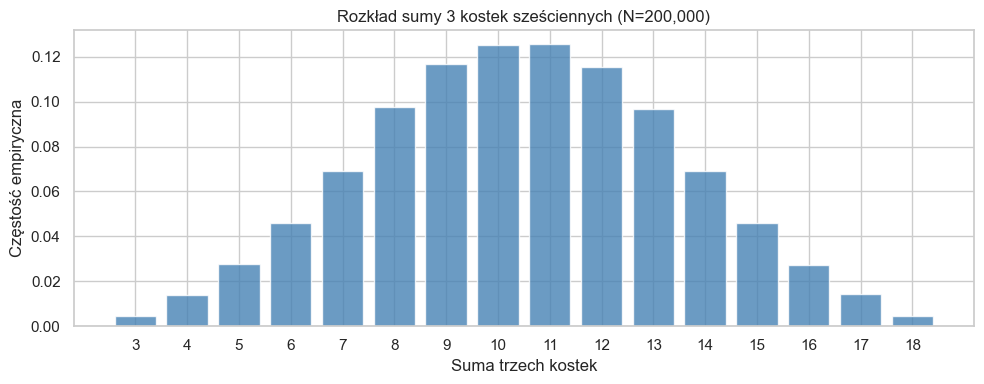

In [9]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N = 200_000

# Rzut trzema kostkami sześciennymi, N razy
kostki = rng.integers(1, 7, size=(N, 3))
sumy = kostki.sum(axis=1)  # suma każdego rzutu

# Rozkład empiryczny
unikalne, liczby = np.unique(sumy, return_counts=True)
czestosci = liczby / N

print(f"P(suma >= 15) = {(sumy >= 15).mean():.4f}")
print(f"P(suma == 3)  = {(sumy == 3).mean():.5f}  (tylko 1,1,1)")
print(f"E[suma]       = {sumy.mean():.3f}  (teoretycznie: 3 * 3.5 = 10.5)")

# Wykres
plt.figure(figsize=(10, 4))
plt.bar(unikalne, czestosci, color='steelblue', alpha=0.8)
plt.xlabel('Suma trzech kostek')
plt.ylabel('Częstość empiryczna')
plt.title(f'Rozkład sumy 3 kostek sześciennych (N={N:,})')
plt.xticks(unikalne)
plt.tight_layout()
plt.show()

# <span style="color:#0f766e; font-weight:700;">9. Zadania obowiązkowe</span>

## <span style="color:#0f766e; font-weight:700;">Zadanie 1</span>

Rozkład t-Studenta — prawdopodobieństwa ogonów i kwantyle.

Instrukcja:
1. Dla rozkładów t(df=3), t(df=10), t(df=30) i N(0,1) oblicz:
   - P(|X| > 1.96),
   - P(|X| > 2.576).
2. Przedstaw wyniki w formie tabeli (4 wiersze × 3 kolumny: df, P(|X|>1.96), P(|X|>2.576)).
3. Skomentuj (krótki komentarz w kodzie), dlaczego różnice maleją przy dużym df.

Wymagane funkcje:
- `stats.t(df=k)`, `stats.norm(0, 1)`
- `.cdf()` — pamiętaj: P(|X|>c) = 2*(1 - cdf(c))

Kryterium zaliczenia:
- poprawna tabela z 4 wierszami i 2 wartościami prawdopodobieństwa,
- komentarz o zbieżności t → N(0,1).

Checkpoint:
- pokaż prowadzącemu tabelę i wyjaśnij, co oznacza df.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 2</span>

Rozkład t-Studenta — kwantyle i granice przedziałów.

Instrukcja:
1. Dla rozkładu t(df=15) wyznacz kwantyle t* spełniające:
   - P(−t* < X < t*) = 0.90 (przedział 90%),
   - P(−t* < X < t*) = 0.95 (przedział 95%),
   - P(−t* < X < t*) = 0.99 (przedział 99%).
2. Powtórz to samo dla N(0,1).
3. Wydrukuj wyniki w postaci tabeli. Dla każdego wiersza zaznacz, o ile % wartość t jest większa od z.

Wymagane funkcje:
- `stats.t(df=15).ppf(q)` — dla przedziału symetrycznego P(−t*<X<t*)=0.95 użyj q=0.975
- `stats.norm(0,1).ppf(q)`

Kryterium zaliczenia:
- poprawne kwantyle dla t(15) i N(0,1),
- kolumna z procentową różnicą.

Checkpoint:
- pokaż tabelę i wskaż, przy której ufności różnica jest największa.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 3</span>

Rozkład chi-kwadrat — pdf, cdf i kwantyle.

Instrukcja:
1. Narysuj pdf rozkładu chi-kwadrat dla df = 2, 5, 10, 20 na jednym wykresie.
2. Dla df=5 oblicz:
   - P(X ≤ 5),
   - P(X > 10),
   - kwantyle: 5., 50., 95. percentyl.
3. Potwierdź, że E[X] = df i Var[X] = 2·df.

Wymagane funkcje:
- `stats.chi2(df=k)`
- `.pdf()`, `.cdf()`, `.ppf()`, `.mean()`, `.var()`

Kryterium zaliczenia:
- wykres z 4 krzywymi,
- poprawne prawdopodobieństwa i kwantyle dla df=5.

Checkpoint:
- pokaż wykres i obliczenia prowadzącemu.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 4</span>

Monte Carlo — estymacja π metodą Buffona.

Instrukcja:
1. Zasymuluj estymację π metodą Buffona (igła Buffona):
   - Rzucamy igłę długości L=1 na podłogę z równoległymi liniami co d=2 (L < d).
   - Środek igły: y ~ Uniform(0, d/2), kąt: θ ~ Uniform(0, π/2).
   - Igła przecina linię, jeśli: y ≤ (L/2)·sin(θ).
   - P(przecięcie) = 2L / (π·d), stąd π ≈ 2L·N / (d·liczba_przecięć).
2. Zasymuluj N=100 000 rzutów.
3. Wydrukuj oszacowanie π i błąd absolutny.
4. Narysuj zbieżność oszacowania (kumulowaną) dla kolejnych rzutów.

Wymagane funkcje:
- `rng.uniform()`
- `np.cumsum()`
- `plt.plot()` ze skalą log na osi x

Kryterium zaliczenia:
- poprawna formuła estymacji π,
- wykres zbieżności kumulowanej.

Checkpoint:
- pokaż wykres i oszacowanie π prowadzącemu.

Dokumentacja:
- https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.uniform.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 5</span>

Monte Carlo — symulacja złożonego zdarzenia.

Instrukcja:
1. W urnie jest 10 kul: 4 czerwone, 3 niebieskie, 3 zielone.
2. Losujemy 4 kule **bez zwracania**.
3. Za pomocą symulacji Monte Carlo (N=100 000) oszacuj:
   - P(co najmniej 2 czerwone),
   - P(wszystkie 4 tego samego koloru),
   - P(dokładnie 1 zielona i dokładnie 1 niebieska).
4. Porównaj z wynikiem analitycznym dla pierwszego prawdopodobieństwa (kombinatoryka).

Wymagane funkcje:
- `rng.choice(a, size, replace=False)` — losowanie bez zwracania
- `np.sum()`, `np.mean()`

Kryterium zaliczenia:
- trzy poprawne oszacowania MC,
- wynik analityczny P(≥2 czerwone) obliczony i porównany.

Checkpoint:
- pokaż wyniki i porównanie z analitycznym.

Dokumentacja:
- https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.choice.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 6</span>

CTG — demonstracja dla rozkładu chi-kwadrat.

Instrukcja:
1. Użyj rozkładu chi-kwadrat χ²(df=2) jako populacji (silnie skośny, E[X]=2, Var[X]=4).
2. Dla n ∈ {5, 15, 50, 200} zasymuluj 8000 próbek rozmiaru n.
3. Oblicz średnią każdej próbki.
4. Narysuj 4 histogramy w siatce 2×2. Na każdym nałóż teoretyczne pdf aproksymacji normalnej.
5. Dodaj podtytuł figury z nazwą rozkładu populacji.

Wymagane funkcje:
- `stats.chi2(df=2).rvs(size=(8000, n), random_state=rng)`
- `.mean(axis=1)`
- `sns.histplot(stat='density')`

Kryterium zaliczenia:
- 4 histogramy w siatce 2×2,
- widoczna zbieżność do normalnego.

Checkpoint:
- pokaż wykresy i wskaż, dla którego n aproksymacja jest już dobra.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.chi2.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 7</span>

Błąd standardowy — obliczenia i interpretacja.

Instrukcja:
1. Dane: populacja z σ=20 (np. wyniki egzaminu).
2. Oblicz SE dla n ∈ {10, 25, 50, 100, 200, 400}.
3. Przedstaw wyniki w tabeli: n, SE, zmiana SE względem n=10.
4. Narysuj wykres SE(n). Opisz punkt n=100 etykietą.

Wymagane funkcje:
- `np.sqrt()`
- `plt.annotate()` do dodania etykiety

Kryterium zaliczenia:
- poprawna tabela SE,
- wykres z etykietą przy n=100.

Checkpoint:
- pokaż tabelę i wykres; wyjaśnij, dlaczego zmniejszenie SE 2× wymaga 4× więcej danych.

Dokumentacja:
- https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.annotate.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 8</span>

CTG i SE — weryfikacja symulacyjna.

Instrukcja:
1. Populacja: rozkład wykładniczy Exponential(scale=5) — E[X]=5, SD[X]=5.
2. Dla n=64 zasymuluj 20 000 próbek. Oblicz średnią każdej próbki.
3. Oblicz:
   - empiryczne mean i SD rozkładu średnich,
   - teoretyczne: μ=5, SE=σ/√n.
4. Sprawdź, czy empiryczne SD ≈ SE (różnica < 0.05).
5. Narysuj histogram średnich z nałożonym pdf N(μ, SE).

Wymagane funkcje:
- `stats.expon(scale=5).rvs(size=(20000, 64), random_state=rng)`
- `.mean(axis=1)`, `.std()`
- `sns.histplot(stat='density')`

Kryterium zaliczenia:
- empiryczne mean i SD bliskie μ i SE,
- wykres histogramu z pdf.

Checkpoint:
- pokaż prowadzącemu tabelę porównawczą i wykres.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.expon.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 9</span>

Porównanie zbieżności CTG dla różnych rozkładów populacji.

Instrukcja:
1. Wybierz 3 rozkłady populacji (różna skośność):
   - symetryczny: Uniform(0,1),
   - umiarkowanie skośny: Exponential(scale=1),
   - bardzo skośny: chi2(df=1).
2. Dla każdego narysuj, jak wygląda rozkład średnich dla n=1, 10, 50 (siatka 3×3).
3. Oceń wizualnie: dla którego rozkładu CTG zbiega najszybciej?

Wymagane funkcje:
- `.rvs(size=(5000, n), random_state=rng)`
- `sns.histplot(stat='density')`

Kryterium zaliczenia:
- siatka 3×3 z histogramami,
- wniosek o szybkości zbieżności.

Checkpoint:
- pokaż siatkę wykresów; wskaż rozkład z najwolniejszą zbieżnością.

Dokumentacja:
- https://seaborn.pydata.org/generated/seaborn.histplot.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 10</span>

Monte Carlo — całkowanie numeryczne.

Instrukcja:
1. Oblicz całkę ∫₀¹ f(x) dx, gdzie f(x) = 4√(1−x²) (ćwiartka koła jednostkowego — wynik = π).
2. Metoda MC:
   - losuj x ~ Uniform(0,1),
   - oblicz f(x) = 4*sqrt(1−x²) dla każdego x,
   - oszacowanie: ∫f(x)dx ≈ mean(f(x)).
3. Uruchom dla N ∈ {100, 1000, 10000, 100000}. Dla każdego wydrukuj oszacowanie i błąd.
4. Narysuj zbieżność (błąd absolutny vs N) na skali log-log.

Wymagane funkcje:
- `rng.uniform(0, 1, size=N)`
- `np.sqrt()`, `np.mean()`
- `plt.loglog()`

Kryterium zaliczenia:
- poprawne oszacowania dla 4 wartości N,
- wykres log-log zbieżności błędu.

Checkpoint:
- pokaż wykres; opisz, jak błąd maleje z N.

Dokumentacja:
- https://numpy.org/doc/stable/reference/generated/numpy.mean.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 11</span>

Rozkład t-Studenta w praktyce — przedział ufności dla średniej.

Wprowadzenie:
Gdy szacujemy μ z małej próby i nie znamy σ, używamy rozkładu t. Przedział ufności (1−α) dla μ:
[x̄ − t* · s/√n,  x̄ + t* · s/√n]
gdzie t* = ppf(1−α/2) dla t(df=n−1).

Instrukcja:
1. Wygeneruj próbę n=15 z N(50, 8) (udajemy, że nie znamy σ).
2. Oblicz x̄ i s z próby.
3. Wyznacz t* dla ufności 95% (df=n−1=14).
4. Oblicz i wydrukuj przedział ufności 95%.
5. Powtórz 1000 razy; policz, w jakim % przypadków prawdziwa μ=50 jest wewnątrz przedziału.

Wymagane funkcje:
- `stats.t(df=n-1).ppf(0.975)`
- `np.mean()`, `np.std(ddof=1)`

Kryterium zaliczenia:
- poprawny przedział ufności dla jednej próby,
- procent pokrycia bliski 95% dla 1000 powtórzeń.

Checkpoint:
- pokaż przedział i procent pokrycia.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 12</span>

Monte Carlo — problem Sekretarki (optymalne zatrzymanie).

Wprowadzenie:
Przeglądam kolejno n=20 kandydatów. Widzę ich jakość (1–100), ale decyzja jest nieodwracalna. Strategia: odrzuć pierwszych k kandydatów (faza obserwacji), potem wybierz pierwszego lepszego od najlepszego w fazie obserwacji.

Instrukcja:
1. Zasymuluj strategię dla k ∈ {0, 1, 2, …, 19} (faza odrzucenia = k kandydatów).
2. Dla każdego k oblicz (N=50 000 symulacji) prawdopodobieństwo wyboru najlepszego kandydata.
3. Narysuj wykres P(wybór najlepszego) jako funkcję k.
4. Znajdź optymalne k i porównaj z teorią: k* ≈ n/e ≈ 7.

Wymagane funkcje:
- `rng.permutation(n)` — losowa kolejność kandydatów
- `np.max()` — najlepszy z fazy obserwacji

Kryterium zaliczenia:
- wykres prawdopodobieństwa vs k,
- zidentyfikowane optymalne k.

Checkpoint:
- pokaż wykres; opisz, gdzie jest maksimum i jak blisko jest n/e.

Dokumentacja:
- https://numpy.org/doc/stable/reference/random/generated/numpy.random.Generator.permutation.html

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 13</span>

Rozkład t vs normalny — wpływ na szerokość przedziału ufności.

Instrukcja:
1. Dla danych z N(0,1) i różnych rozmiarów próby n ∈ {5, 10, 20, 50, 100}:
   - oblicz szerokość przedziału ufności 95% opartego na t(df=n−1) × SE,
   - oblicz szerokość przedziału opartego na z = 1.96 × SE,
   - zakładaj σ=1 (znana), SE=1/√n.
2. Wydrukuj tabelę: n, szerokość(t), szerokość(z), stosunek t/z.
3. Narysuj obie szerokości jako funkcję n.

Wymagane funkcje:
- `stats.t(df=n-1).ppf(0.975)`
- `stats.norm(0,1).ppf(0.975)` → 1.96

Kryterium zaliczenia:
- poprawna tabela i wykres,
- wniosek: przy jakim n różnica t/z jest < 5%?

Checkpoint:
- pokaż tabelę i wykres; wskaż, od którego n można używać z zamiast t.

Dokumentacja:
- https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.t.html

In [ ]:
# tutaj dodaj swój kod

# <span style="color:#0f766e; font-weight:700;">10. Zadania dodatkowe</span>

## <span style="color:#0f766e; font-weight:700;">Zadanie 14 - dodatkowe</span>

Rozkład F — porównanie wariancji.

Instrukcja:
1. Narysuj pdf rozkładu F(df1, df2) dla par: (1,1), (5,5), (10,30), (30,100).
2. Dla F(5, 10) oblicz P(X > 3.33) — odpowiada to testowi F przy α=0.05 (górny kwantyl).
3. Sprawdź: `stats.f(5, 10).ppf(0.95)` — porównaj z wartością tabelaryczną 3.33.

Wymagane funkcje:
- `stats.f(dfn, dfd)`, `.pdf()`, `.cdf()`, `.ppf()`

Kryterium zaliczenia:
- wykres 4 krzywych, obliczone P(X>3.33) i kwantyl 95%.

Checkpoint:
- pokaż wykres i obliczenia.

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 15 - dodatkowe</span>

Bootstrap — nieparametryczna alternatywa dla CTG.

Wprowadzenie:
Bootstrap to metoda estymacji SE bez założeń o rozkładzie populacji. Wielokrotnie losujemy próbę ze zwracaniem z naszych danych i obliczamy statystykę. Rozproszenie tych statystyk szacuje SE.

Instrukcja:
1. Wygeneruj próbę n=30 z silnie skośnego rozkładu chi2(df=1).
2. Oblicz x̄ tej próby.
3. Wykonaj B=5000 próbek bootstrapowych (losowanie ze zwracaniem z oryginalnej próby).
4. Oblicz SE bootstrapowe = std(średnich bootstrapowych).
5. Porównaj z teoretycznym SE = σ_pop / √n (σ_pop = √(2·df) = √2 dla df=1).
6. Narysuj histogram średnich bootstrapowych.

Wymagane funkcje:
- `rng.choice(proba, size=(B, n), replace=True)`
- `.mean(axis=1)`, `.std()`

Kryterium zaliczenia:
- poprawne SE bootstrapowe bliskie teoretycznemu,
- histogram bootstrapowych średnich.

Checkpoint:
- pokaż porównanie SE i histogram.

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 16 - dodatkowe</span>

CTG dla proporcji — twierdzenie de Moivre'a-Laplace'a.

Wprowadzenie:
Proporcja sukcesów p̂ = X/n w próbie z Binomial(n,p) ma w przybliżeniu rozkład normalny:
p̂ ~ N(p, √(p(1-p)/n)) dla dużego n.

Instrukcja:
1. Ustaw p=0.35, n=50.
2. Zasymuluj 20 000 proporcji: dla każdej próbki n=50 oblicz p̂ = liczba sukcesów / n.
3. Narysuj histogram p̂ + aproksymację normalną.
4. Oblicz SE = √(p(1-p)/n) i porównaj z empirycznym std(p̂).
5. Oblicz P(p̂ > 0.45) dwoma sposobami: MC i z aproksymacji normalnej.

Wymagane funkcje:
- `rng.binomial(n, p, size=20000)`
- `stats.norm(p, se).cdf()`

Kryterium zaliczenia:
- wykres histogramu z aproksymacją,
- porównanie P(p̂>0.45) obu metodami.

Checkpoint:
- pokaż wykres i tabelę porównawczą.

In [ ]:
# tutaj dodaj swój kod

## <span style="color:#0f766e; font-weight:700;">Zadanie 17 - dodatkowe</span>

SE i prawo malejących zwrotów — planowanie badania.

Instrukcja:
1. Chcesz zmierzyć średni czas reakcji (σ=80 ms) z dokładnością SE ≤ 5 ms.
2. Oblicz minimalny n: n ≥ (σ/SE_max)².
3. Dla n wyliczonego w pkt 2 zasymuluj 10 000 próbek i sprawdź, że empiryczne SD(x̄) ≤ 5.
4. Narysuj wykres SE(n) z zaznaczoną wartością n* i linią SE_max=5.

Wymagane funkcje:
- `np.ceil()` do zaokrąglenia n do góry
- `stats.norm(mu, sigma).rvs()`

Kryterium zaliczenia:
- poprawne n*, weryfikacja symulacyjna SE ≤ 5.

Checkpoint:
- pokaż obliczenie n* i wynik symulacji.

In [ ]:
# tutaj dodaj swój kod

# <span style="color:#0f766e; font-weight:700;">11. Najczęstsze błędy</span>

- mylenie SE (błąd standardowy średniej) z s (odchylenie standardowe danych) — SE = s/√n, a nie s,
- użycie N(0,1) zamiast t(df=n−1) przy małej próbie i nieznanym σ — zawyża precyzję przedziałów,
- interpretowanie CTG jako twierdzenia o danych: CTG dotyczy rozkładu **średniej**, nie indywidualnych obserwacji,
- brak `ddof=1` w `np.std()` przy obliczaniu odchylenia z próby — daje obciążony estymator σ,
- zbyt mała liczba symulacji Monte Carlo (N < 1000) — duże błędy losowe, mylące wyniki,
- wnioskowanie z jednej symulacji bez uśredniania — wynik może być daleki od wartości oczekiwanej.